<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>


## Домашнее задание. Решение конкурса на kaggle

Две части этого домашнего задания:

### Отправить ваши предсказания в Stepik.
За прохождение определенных порогов будут начисляться баллы. Эта часть оценивается из 5 баллов.

1) $1.00 \geqslant score \geqslant 0.84$ --- 5 баллов

2) $0.84 > score \geqslant 0.77$ --- 4 балла

3) $0.77 > score \geqslant 0.70$ --- 3 балла

4) $0.70 > score \geqslant 0.65$ --- 2 балла

5) $0.65 > score \geqslant 0.6$ --- 1 балл

6) $0.60 > score$ --- 0 баллов

### Сделать полноценный отчет о вашей работе.
Опишите, как вы обработали данные, какие модели попробовали и какие результаты получились (максимум 10 баллов). За каждую выполненную часть будет начислено определенное количество баллов. В этом пункте вам необходимо отправить файл в формате .ipynb на Stepik --- для этого в домашнем задании есть отдельный шаг. Этот пункт оценивается из 10 баллов.


### Контест на Kaggle
Для вашего удобства мы подготовили [контест на Kaggle](https://www.kaggle.com/c/advanced-dls-spring-2021/). Тестирующая система на Kaggle выдает те же баллы, что и Stepik. Мы рекомендуем в качестве основной тестирующей системы использовать именно Kaggle, а затем сдать лучшую посылку на Stepik. Так вы привыкните работать с Kaggle.


### Несколько замечаний по выполнению работы
* Во всех пунктах указания это минимальный набор вещей, которые стоит сделать. Если вы можете сделать какой-то шаг лучше или добавить что-то свое --- дерзайте!
* Пожалуйста, перед сдачей ноутбука убедитесь, что работа чистая и понятная. Это значительно облегчит проверку и повысит ваши ожидаемые баллы.
* Если у вас будут проблемы с решением или хочется совета, то пишите в наш чат в телеграме.


Данные: [train.csv](https://drive.google.com/file/d/1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K/view?usp=share_link),
[test.csv](https://drive.google.com/file/d/1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r/view?usp=share_link), [submission.csv](https://drive.google.com/file/d/199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y/view?usp=share_link).

Если ссылки на данные не работают, их можно скачать [на Kaggle](https://www.kaggle.com/competitions/advanced-dls-spring-2021/data).

### Как проверять?

Ставьте полный балл, если выполнены все рекомендации или сделано что-то более интересное и сложное. За каждый отсустствующий пункт из рекомендации снижайте 1 балл.

**Если решение верное, но не удовлетворяет вашим эстетическим предпочтениям, за это баллы снижать не нужно.**

### Метрика

Перед решением любой задачи важно понимать, как будет оцениваться ваше решение. В данном случае мы используем стандартную для задачи классификации метрику ROC-AUC. Ее можно вычислить, используя только предсказанные вероятности и истинные классы без конкретного порога классификации + она раотает даже если классы в данных сильно несбалансированны (примеров одного класса в десятки раз больше примеров длугого). Именно поэтому она очень удобна для соревнований.

Посчитать ее легко:


In [2]:
from sklearn.metrics import roc_auc_score

y_true = [
    0,
    1,
    1,
    0,
    1
]

y_predictions = [
    0.1,
    0.9,
    0.4,
    0.6,
    0.61
]

roc_auc_score(y_true, y_predictions)

0.8333333333333333

## Бизнес - описание

Бизнес-постановка задачи предсказания оттока клиентов может быть сформулирована следующим образом:

**Цель:**
Разработать модель машинного обучения, которая позволит прогнозировать вероятность оттока клиентов (churn) на основе их исторических данных и характеристик. Это позволит компании своевременно принимать меры для удержания клиентов, снижения потерь и увеличения прибыли.

**Проблема:**
Отток клиентов (churn) — это ситуация, когда клиенты прекращают пользоваться услугами компании. Это приводит к потере доходов, увеличению затрат на привлечение новых клиентов и снижению общей прибыльности бизнеса. Предсказание оттока на ранних этапах позволяет компании предпринимать proactive меры для удержания клиентов, что дешевле и эффективнее, чем привлечение новых.

# Исследование

In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [4]:
COLORS = ['#dbd795', '#95dbd7', '#95dbb0', '#95b0db']

## Загрузка данных (2 балла)

1) Посмотрите на случайные строчки.

2) Посмотрите, есть ли в датасете незаполненные значения (nan'ы) с помощью data.isna() или data.info() и, если нужно, замените их на что-то. Будет хорошо, если вы построите табличку с количеством nan в каждой колонке.

In [5]:
# !gdown 1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K  # train.csv
# !gdown 1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r  # test.csv
# !gdown 199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y  # submission.csv

> Изпользуем API взаимодействия с kaggle

In [6]:
!kaggle competitions download -c advanced-dls-spring-2021

advanced-dls-spring-2021.zip: Skipping, found more recently modified local copy (use --force to force download)


In [7]:
df = pd.read_csv('./train.csv')

In [8]:
# Для вашего удобства списки с именами разных колонок

# Числовые признаки
num_cols = [
    'ClientPeriod',
    'MonthlySpending',
    'TotalSpent'
]

# Категориальные признаки
cat_cols = [
    'Sex',
    'IsSeniorCitizen',
    'HasPartner',
    'HasChild',
    'HasPhoneService',
    'HasMultiplePhoneNumbers',
    'HasInternetService',
    'HasOnlineSecurityService',
    'HasOnlineBackup',
    'HasDeviceProtection',
    'HasTechSupportAccess',
    'HasOnlineTV',
    'HasMovieSubscription',
    'HasContractPhone',
    'IsBillingPaperless',
    'PaymentMethod'
]

feature_cols = num_cols + cat_cols
target_col = 'Churn'

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5282 entries, 0 to 5281
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              5282 non-null   int64  
 1   MonthlySpending           5282 non-null   float64
 2   TotalSpent                5282 non-null   object 
 3   Sex                       5282 non-null   object 
 4   IsSeniorCitizen           5282 non-null   int64  
 5   HasPartner                5282 non-null   object 
 6   HasChild                  5282 non-null   object 
 7   HasPhoneService           5282 non-null   object 
 8   HasMultiplePhoneNumbers   5282 non-null   object 
 9   HasInternetService        5282 non-null   object 
 10  HasOnlineSecurityService  5282 non-null   object 
 11  HasOnlineBackup           5282 non-null   object 
 12  HasDeviceProtection       5282 non-null   object 
 13  HasTechSupportAccess      5282 non-null   object 
 14  HasOnlin

In [10]:
df.isna().sum().sum()

0

> пропусков нет, однако TotalSpent не является числом, значит есть не числовые значения, например пробел

In [11]:
df.sample(10).T

,4146,3279,4379,246,3211,2373,2621,5095,2111,635
ClientPeriod,48,2,3,68,10,62,65,2,33,59
MonthlySpending,103.85,30.9,55.35,108.45,29.65,96.1,19.55,20.7,91.25,101.1
TotalSpent,4946.05,59.05,165.2,7176.55,291.4,6001.45,1218.65,39.85,2964.05,6039.9
Sex,Female,Female,Female,Male,Female,Male,Male,Female,Male,Female
IsSeniorCitizen,0,0,0,0,1,0,0,0,0,0
HasPartner,No,No,No,No,No,Yes,No,No,Yes,Yes
HasChild,No,No,No,No,No,No,No,No,No,No
HasPhoneService,Yes,No,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes
HasMultiplePhoneNumbers,Yes,No phone service,No,Yes,No phone service,Yes,No,No,No,Yes
HasInternetService,Fiber optic,DSL,DSL,Fiber optic,DSL,Fiber optic,No,No,Fiber optic,Fiber optic


In [12]:
df.loc[df.TotalSpent == ' ']['TotalSpent'].count()

9

In [13]:
df.TotalSpent = df.TotalSpent.replace(' ', np.nan)
df.TotalSpent = df.TotalSpent.astype(float)

In [14]:
df.loc[df.TotalSpent.isna()]


,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
1048,0,25.75,NaN,Male,0,Yes,Yes,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,0
1707,0,73.35,NaN,Female,0,Yes,Yes,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,0
2543,0,19.70,NaN,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,0
3078,0,80.85,NaN,Female,0,Yes,Yes,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,0
3697,0,20.00,NaN,Female,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,0
4002,0,61.90,NaN,Male,0,No,Yes,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),0
4326,0,25.35,NaN,Male,0,Yes,Yes,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,0
4551,0,52.55,NaN,Female,0,Yes,Yes,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),0
4598,0,56.05,NaN,Female,0,Yes,Yes,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),0


> Так как при TotalSpent = Nan ClientPerion = 0 будем считать что в этих условиях TotalSpent = 0

In [15]:
df.TotalSpent = df.TotalSpent.fillna(0)

## Анализ данных (3 балла)

1) Для численных призанков постройте гистограмму (*plt.hist(...)*) или boxplot (*plt.boxplot(...)*). Для категориальных посчитайте количество каждого значения для каждого признака. Для каждой колонки надо сделать *data.value_counts()* и построить bar диаграммы *plt.bar(...)* или круговые диаграммы *plt.pie(...)* (хорошо, елси вы сможете это сделать на одном гарфике с помощью *plt.subplots(...)*).

2) Посмотрите на распределение целевой переменной и скажите, являются ли классы несбалансированными.

3) (Если будет желание) Поиграйте с разными библиотеками для визуализации - *sns*, *pandas_visual_analysis*, etc.

Второй пункт очень важен, потому что существуют задачи классификации с несбалансированными классами. Например, это может значить, что в датасете намного больше примеров 0 класса. В таких случаях нужно 1) не использовать accuracy как метрику 2) использовать методы борьбы с imbalanced dataset (обычно если датасет сильно несбалансирован, т.е. класса 1 в 20 раз меньше класса 0).

### Описание переменных

Описание переменных в задаче предсказания оттока пользователей может быть следующим:


| Название поля               | Описание                                                                                       |
|-----------------------------|-----------------------------------------------------------------------------------------------|
| **ClientPeriod**            | Период времени (в месяцах, днях или годах), в течение которого клиент пользуется услугами компании. Может указывать на лояльность клиента. |
| **MonthlySpending**         | Ежемесячные расходы клиента на услуги компании. Это может быть важным индикатором финансовой вовлеченности клиента. |
| **TotalSpent**              | Общая сумма, которую клиент потратил за все время пользования услугами компании. Отражает общую удовлетворенность клиента. |
| **Sex**                     | Пол клиента (например, "Male", "Female"). Может использоваться для анализа различий в поведении. |
| **IsSeniorCitizen**         | Указывает, является ли клиент пенсионером (1) или нет (0). Пенсионеры могут иметь другие модели поведения. |
| **HasPartner**              | Указывает, есть ли у клиента партнер (1) или нет (0). Наличие партнера может влиять на решения о продолжении использования услуг. |
| **HasChild**                | Указывает, есть ли у клиента дети (1) или нет (0). Наличие детей может влиять на потребности и предпочтения клиента. |
| **HasPhoneService**         | Указывает, подключена ли у клиента услуга телефонной связи (1) или нет (0).                   |
| **HasMultiplePhoneNumbers** | Указывает, использует ли клиент несколько телефонных номеров (1) или нет (0).                 |
| **HasInternetService**      | Указывает, подключена ли у клиента услуга интернета (1) или нет (0).                          |
| **HasOnlineSecurityService**| Указывает, подключена ли у клиента услуга онлайн-безопасности (1) или нет (0).                |
| **HasOnlineBackup**         | Указывает, подключена ли у клиента услуга онлайн-резервного копирования (1) или нет (0).      |
| **HasDeviceProtection**     | Указывает, подключена ли у клиента услуга защиты устройств (1) или нет (0).                   |
| **HasTechSupportAccess**    | Указывает, есть ли у клиента доступ к технической поддержке (1) или нет (0).                  |
| **HasOnlineTV**             | Указывает, подключена ли у клиента услуга онлайн-телевидения (1) или нет (0).                 |
| **HasMovieSubscription**    | Указывает, есть ли у клиента подписка на фильмы (1) или нет (0).                              |
| **HasContractPhone**        | Указывает, заключен ли у клиента контракт на телефонную связь (1) или нет (0).                |
| **IsBillingPaperless**      | Указывает, использует ли клиент безбумажный биллинг (1) или нет (0). Безбумажный биллинг может быть индикатором предпочтений клиента в отношении цифровых услуг. |
| **PaymentMethod**           | Способ оплаты, который использует клиент (например, "Credit Card", "Bank Transfer", "Electronic Check"). Может влиять на удобство и вероятность оттока. |



In [16]:
plt.style.use('ggplot')

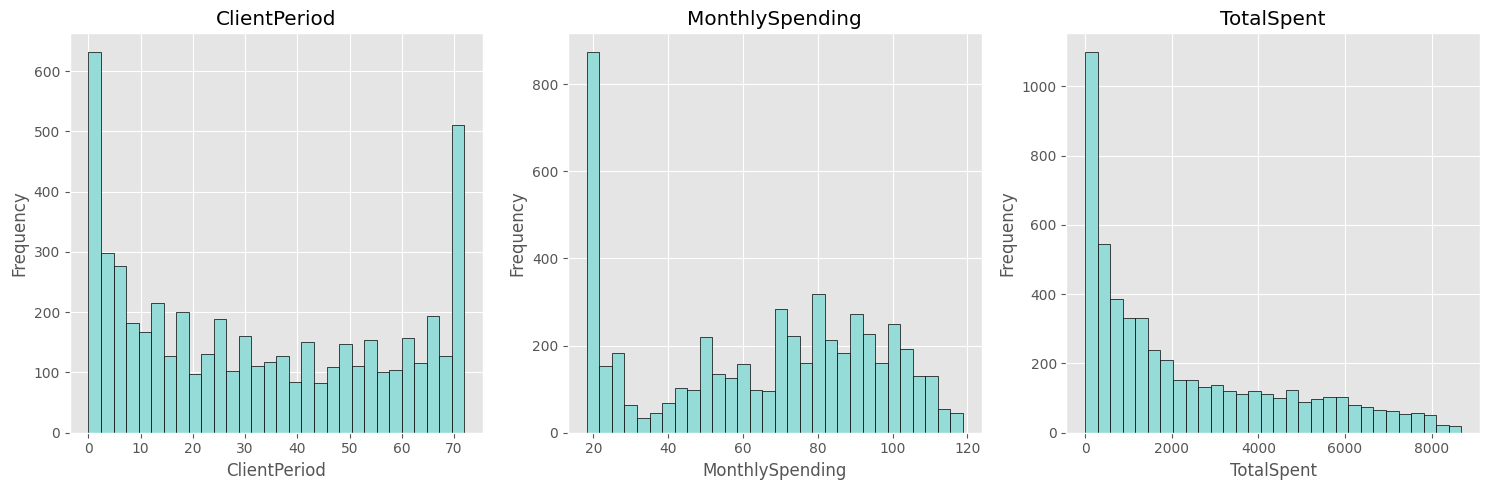

In [17]:
fig, axes = plt.subplots(nrows=1, ncols=len(num_cols), figsize=(15, 5))

for i, feature in enumerate(num_cols):
    axes[i].hist(df[feature], bins=30, color='#95dbd7', edgecolor='black')
    axes[i].set_title(feature)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

> По этим рисункам видно, что возможно существует большое количество пользователй с небольшим временем присутствия у провайдера. Поведение признаков подтверждает что при небольшом периоде ежемесячные платежи и общие затраты минимальны

In [110]:
len(cat_cols)

16

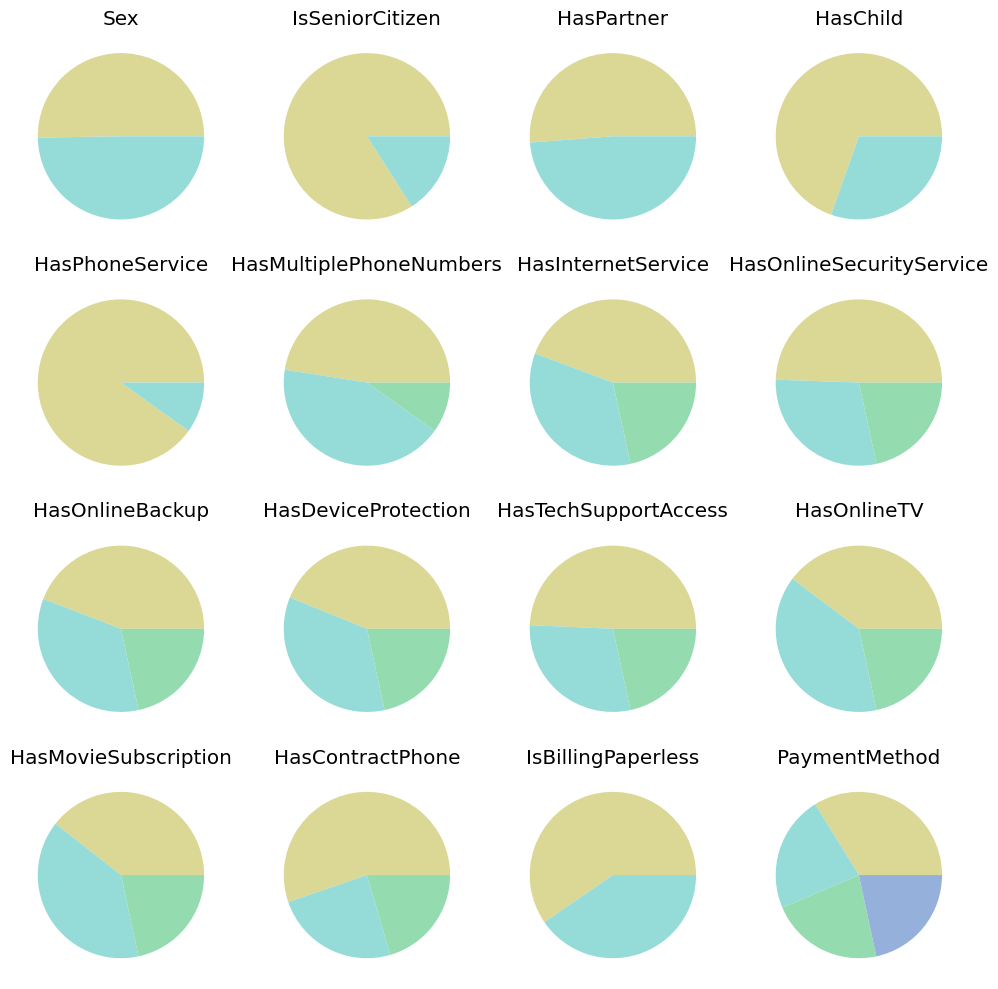

In [18]:

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
axes = axes.flatten()
for i, feature in enumerate(cat_cols):
    category_counts = df[feature].value_counts()
    axes[i].pie(category_counts, colors=COLORS)
    axes[i].set_title(feature)
plt.tight_layout()
plt.show()

> В общем и целом категорийные признаки имеют довольно сбалансированное распределение

> Создадим необходимые процедуры для анализа данных

In [19]:
# Отображение долей типов данных в серии
def show_pie(feature: pd.Series):
    data = feature.value_counts()
    labels = [f'{l} - {k}' for l, k in data.items()]
    plt.pie(data, colors=COLORS, labels=labels, autopct='%1.1f%%')
    plt.show()

In [20]:
from scipy.stats import chi2_contingency

# Расчет корреляции между категорийныпризнаком и таргетом
def detect_cross(feature: pd.Series, target: pd.Series = df[target_col]):
    contingency_table = pd.crosstab(feature, target)
    display(contingency_table)
    chi2, p_value, _, _ = chi2_contingency(contingency_table)
    if p_value < 0.05:
        print('наблюдается корреляция')
    else:
        print('корреляции нет')
    print(f"P-value: {p_value}")

### Churn ( отток )- Целевая переменная

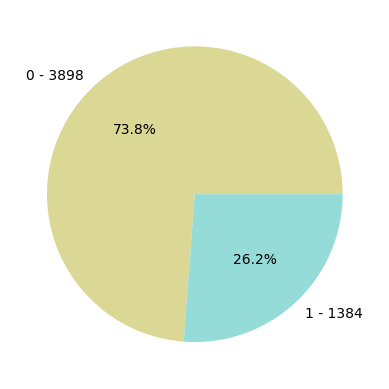

In [21]:
show_pie(df.Churn)

> Присутствует дисбаланс классов, но в целом не критичный

### ClientPeriod Период времени, в течение которого клиент пользуется услугами компании.

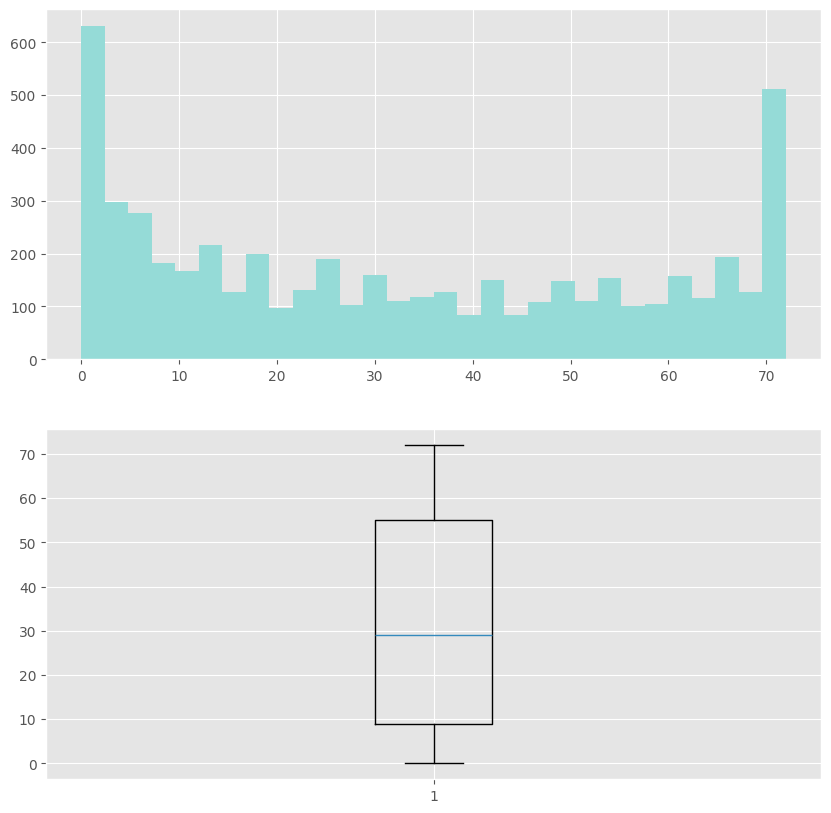

In [22]:
fig, ax = plt.subplots(2, figsize=(10, 10))
ax[0].hist(df.ClientPeriod, bins=30, color=COLORS[1])
ax[1].boxplot(df.ClientPeriod)
plt.show()

In [23]:
df.ClientPeriod.describe()

count    5282.000000
mean       32.397009
std        24.550326
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: ClientPeriod, dtype: float64

Рассмотрим область с маленьким присутствием пользователя

<Axes: >

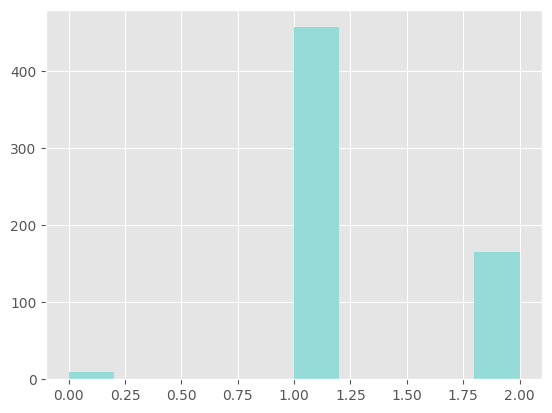

In [25]:
df.loc[df.ClientPeriod <= 2].ClientPeriod.hist(bins=10, color=COLORS[1])

> Возможно сделать отдельную переменную для клиентов 1 месяца сотрудничества

In [26]:
df['isNew'] = False
df.loc[df.ClientPeriod <= 2, 'isNew'] = True

In [27]:
df.isNew.value_counts()

isNew
False    4651
True      631
Name: count, dtype: int64

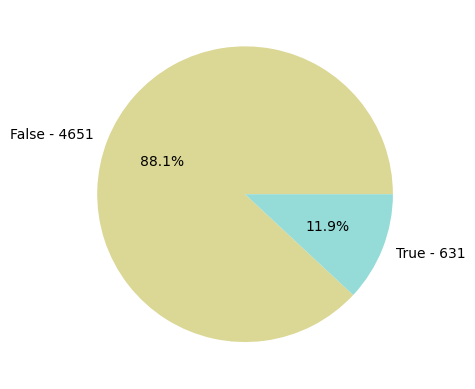

In [28]:
show_pie(df.isNew)

In [29]:
detect_cross(df.isNew)

Churn,0,1
isNew,,
False,3633,1018
True,265,366


наблюдается корреляция
P-value: 4.3322721964465575e-83


> Есть корреляция с оттоком с новыми клиентами

### MonthlySpending - Ежемесячные расходы клиента на услуги компании

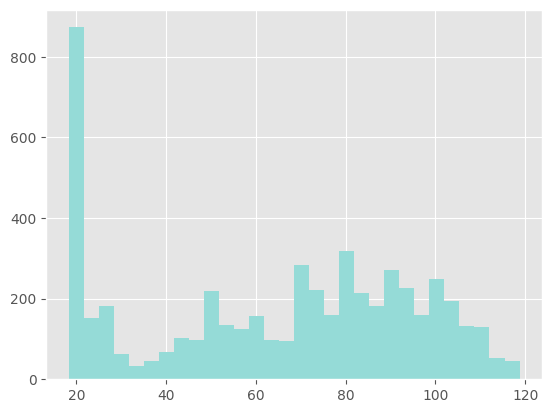

In [30]:
df.MonthlySpending.hist(bins=30, color=COLORS[1])
plt.show()

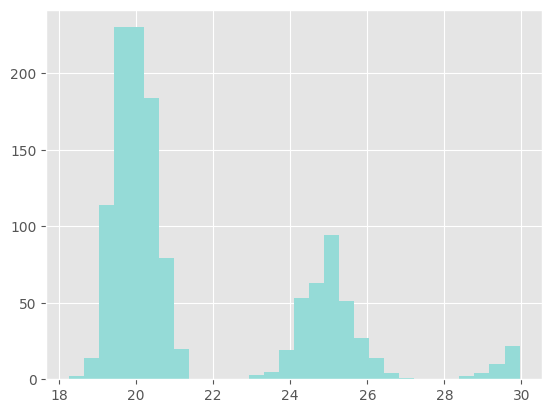

In [31]:
df.loc[df.MonthlySpending <= 30].MonthlySpending.hist(bins=30, color=COLORS[1])
plt.show()

In [32]:
df.loc[df.MonthlySpending <= 30].MonthlySpending.count()

1245

> Создадим переменную для клиентов которые немного платят в месяц (< 30)

In [33]:
df['isMonthlyLowSpending'] = False
df.loc[df.MonthlySpending <= 30, 'isMonthlyLowSpending'] = True

In [34]:
df.isMonthlyLowSpending.value_counts()

isMonthlyLowSpending
False    4037
True     1245
Name: count, dtype: int64

In [35]:
detect_cross(df.isMonthlyLowSpending)

Churn,0,1
isMonthlyLowSpending,,
False,2774,1263
True,1124,121


наблюдается корреляция
P-value: 1.8258282052566708e-51


> Корреляция с целевой переменной не высокая

### TotalSpent - Общая сумма, которую клиент потратил

In [36]:
df.TotalSpent.describe()

count    5282.000000
mean     2287.486161
std      2269.049195
min         0.000000
25%       395.725000
50%      1405.650000
75%      3795.212500
max      8684.800000
Name: TotalSpent, dtype: float64

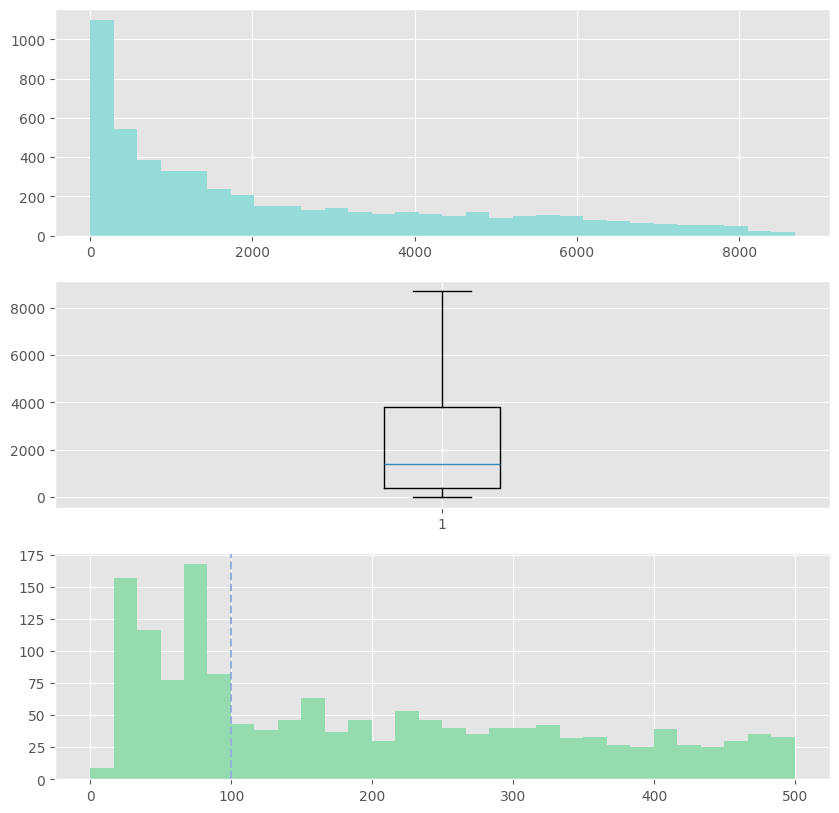

In [37]:
fig, ax = plt.subplots(3, figsize=(10, 10))
ax[0].hist(df.TotalSpent, bins=30, color=COLORS[1])
ax[1].boxplot(df.TotalSpent)
ax[2].hist(df.loc[df.TotalSpent <= 500, 'TotalSpent'], bins=30, color=COLORS[2])
ax[2].axvline(x=100, color=COLORS[3], linestyle='--')
plt.show()

> Видим что значения сильно смещены в нулевую зону, однако близлежащая зона также плавно заполнена. Рассмотрим платежи не более 500. Создадим флаг для клиентов менее 100

In [38]:
df['isLowSpending'] = False
df.loc[df.TotalSpent <= 100, 'isLowSpending'] = True

In [39]:
df.loc[df.isLowSpending, 'isLowSpending'].count()

610

In [40]:
detect_cross(df.isLowSpending)

Churn,0,1
isLowSpending,,
False,3607,1065
True,291,319


наблюдается корреляция
P-value: 2.0485827749719017e-54


> Есть корреляция с отттоком

### Sex - Пол клиента

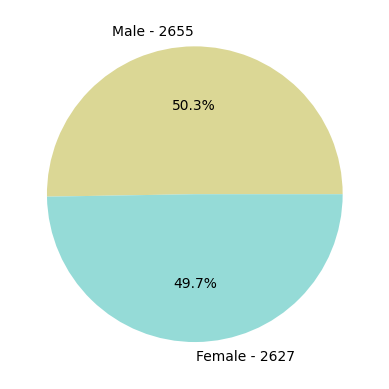

In [41]:
show_pie(df.Sex)

In [42]:
detect_cross(df.Sex, df.Churn)

Churn,0,1
Sex,,
Female,1929,698
Male,1969,686


корреляции нет
P-value: 0.5661255394927714


> пропусков нет необходима кодировка. Предварительно  переменная не влияет на таргет

### IsSeniorCitizen - Является ли клиент пенсионером

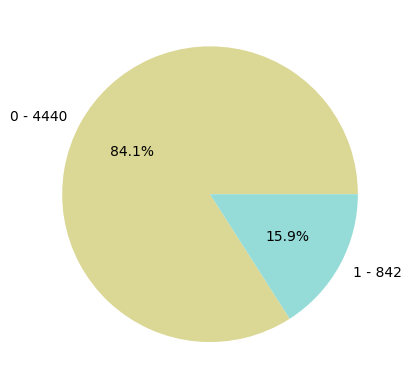

In [43]:
show_pie(df.IsSeniorCitizen)

In [44]:
detect_cross(df.IsSeniorCitizen, df.Churn)

Churn,0,1
IsSeniorCitizen,,
0,3410,1030
1,488,354


наблюдается корреляция
P-value: 6.745956242923248e-30


> пропусков нет кодировка не нужна

### HasPartner - Есть ли у клиента партнер

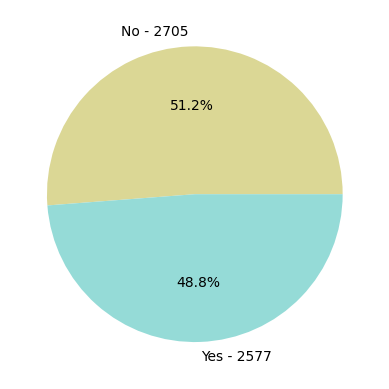

In [45]:
show_pie(df.HasPartner)

In [46]:
detect_cross(df.HasPartner, df.Churn)

Churn,0,1
HasPartner,,
No,1824,881
Yes,2074,503


наблюдается корреляция
P-value: 5.9150430666764906e-27


> пропусков нет необходима кодировка, вожможно влияние на таргет

### HasChild -  Есть ли у клиента дети

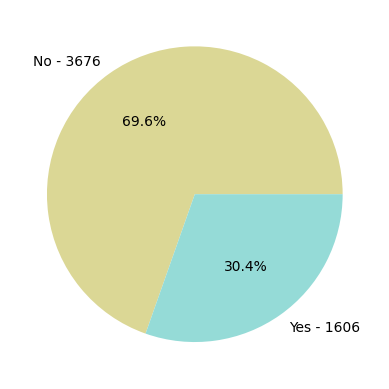

In [47]:
show_pie(df.HasChild)

In [48]:
detect_cross(df.HasChild, df.Churn)

Churn,0,1
HasChild,,
No,2538,1138
Yes,1360,246


наблюдается корреляция
P-value: 1.9866534733080703e-32


> Требуется кодировка, Есть корреляция с таргетом

### HasPhoneService - Подключена ли у клиента услуга телефонной связи

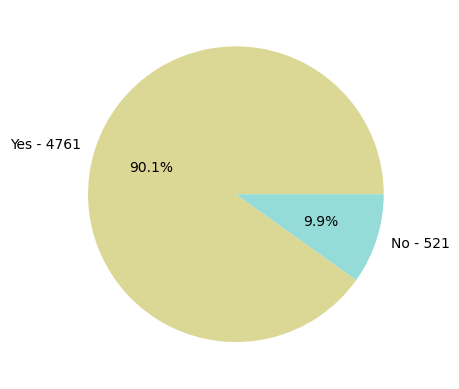

Churn,0,1
HasPhoneService,,
No,392,129
Yes,3506,1255


корреляции нет
P-value: 0.46173681534370814


In [49]:
feature = df.HasPhoneService
show_pie(feature)
detect_cross(feature)

> Требуется кодировка

### HasMultiplePhoneNumbers - Использует ли клиент несколько телефонных номеров

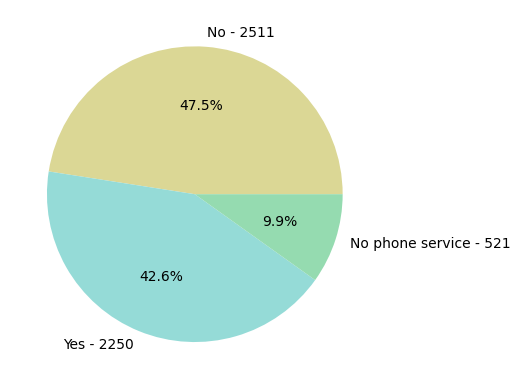

Churn,0,1
HasMultiplePhoneNumbers,,
No,1891,620
No phone service,392,129
Yes,1615,635


наблюдается корреляция
P-value: 0.015982204267404418


In [50]:
feature = df.HasMultiplePhoneNumbers
show_pie(feature)
detect_cross(feature)

### HasInternetService - Подключена ли у клиента услуга интернета

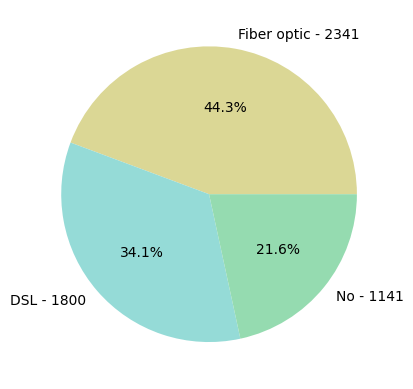

Churn,0,1
HasInternetService,,
DSL,1458,342
Fiber optic,1381,960
No,1059,82


наблюдается корреляция
P-value: 3.5800183642948692e-115


In [51]:
feature = df.HasInternetService
show_pie(feature)
detect_cross(feature)

### HasOnlineSecurityService - Подключена ли у клиента услуга онлайн-безопасности

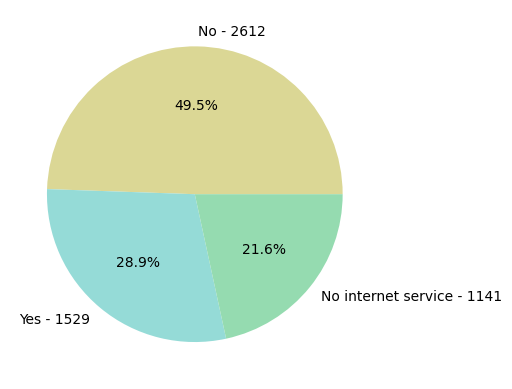

Churn,0,1
HasOnlineSecurityService,,
No,1518,1094
No internet service,1059,82
Yes,1321,208


наблюдается корреляция
P-value: 1.9277532559288986e-146


In [52]:
feature = df.HasOnlineSecurityService
show_pie(feature)
detect_cross(feature)

### HasOnlineBackup - Подключена ли у клиента услуга онлайн-резервного копирования

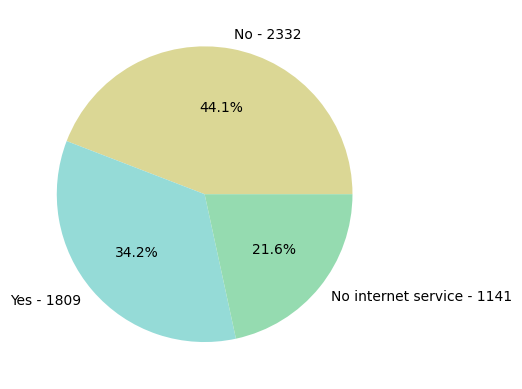

Churn,0,1
HasOnlineBackup,,
No,1407,925
No internet service,1059,82
Yes,1432,377


наблюдается корреляция
P-value: 2.2877886906476973e-100


In [53]:
feature = df.HasOnlineBackup
show_pie(feature)
detect_cross(feature)

### HasDeviceProtection - Подключена ли у клиента услуга защиты устройств

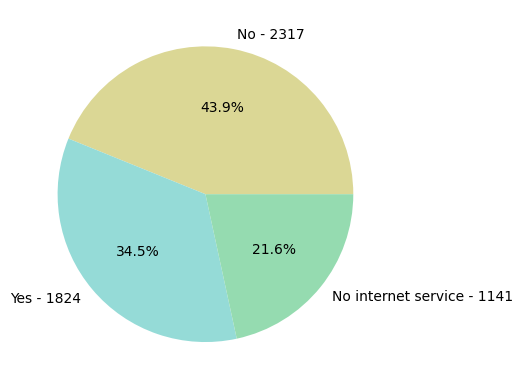

Churn,0,1
HasDeviceProtection,,
No,1417,900
No internet service,1059,82
Yes,1422,402


наблюдается корреляция
P-value: 3.471351613535349e-92


In [54]:
feature = df.HasDeviceProtection
show_pie(feature)
detect_cross(feature)

### HasTechSupportAccess - Есть ли у клиента доступ к технической поддержке

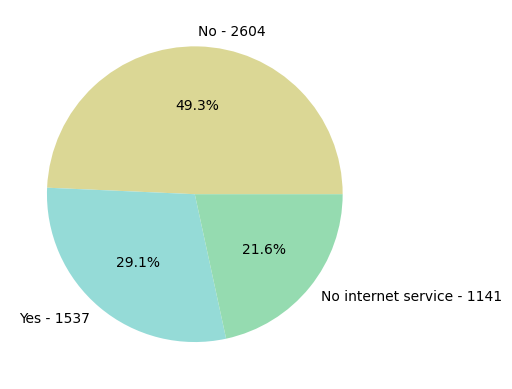

Churn,0,1
HasTechSupportAccess,,
No,1530,1074
No internet service,1059,82
Yes,1309,228


наблюдается корреляция
P-value: 1.5762667529598213e-135


In [55]:
feature = df.HasTechSupportAccess
show_pie(feature)
detect_cross(feature)

### HasOnlineTV - Подключена ли у клиента услуга онлайн-телевидения

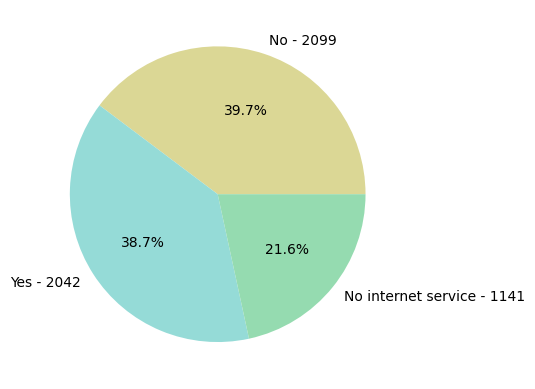

Churn,0,1
HasOnlineTV,,
No,1399,700
No internet service,1059,82
Yes,1440,602


наблюдается корреляция
P-value: 1.4564312480228057e-61


In [56]:
feature = df.HasOnlineTV
show_pie(feature)
detect_cross(feature)

### HasMovieSubscription - Есть ли у клиента подписка на фильмы

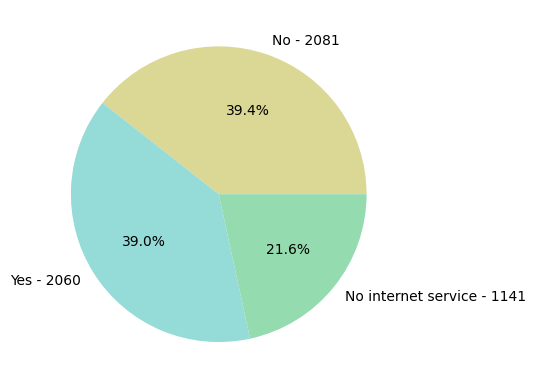

Churn,0,1
HasMovieSubscription,,
No,1376,705
No internet service,1059,82
Yes,1463,597


наблюдается корреляция
P-value: 1.3012505398296487e-62


In [57]:
feature = df.HasMovieSubscription
show_pie(feature)
detect_cross(feature)

### HasContractPhone - заключен ли у клиента контракт на телефонную связь

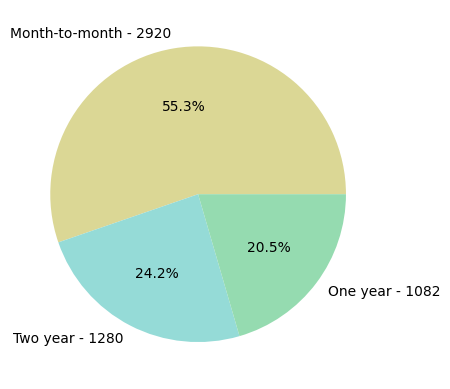

Churn,0,1
HasContractPhone,,
Month-to-month,1689,1231
One year,962,120
Two year,1247,33


наблюдается корреляция
P-value: 3.576816377400634e-192


In [58]:
feature = df.HasContractPhone
show_pie(feature)
detect_cross(feature)

### IsBillingPaperless - Использует ли клиент безбумажный биллинг

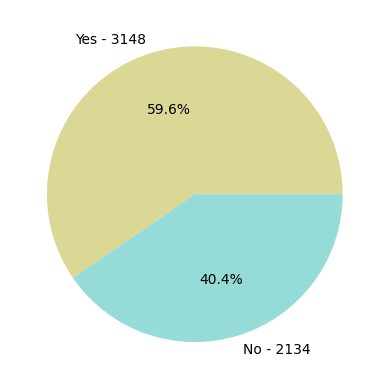

Churn,0,1
IsBillingPaperless,,
No,1796,338
Yes,2102,1046


наблюдается корреляция
P-value: 5.771204783785924e-45


In [59]:
feature = df.IsBillingPaperless
show_pie(feature)
detect_cross(feature)

### PaymentMethod - Способ оплаты

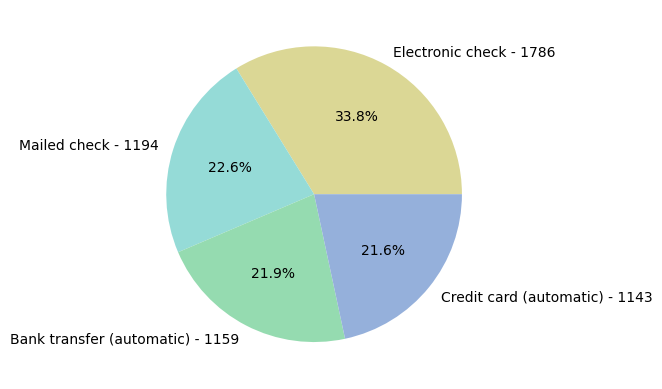

Churn,0,1
PaymentMethod,,
Bank transfer (automatic),964,195
Credit card (automatic),978,165
Electronic check,992,794
Mailed check,964,230


наблюдается корреляция
P-value: 5.398667658412775e-102


In [60]:
feature = df.PaymentMethod
show_pie(feature)
detect_cross(feature)

## Применение линейных моделей (3 балла)

1) Обработайте данные для того, чтобы к ним можно было применить LogisticRegression. Т.е. отнормируйте числовые признаки, а категориальные закодируйте с помощью one-hot-encoding'а.





2) С помощью кроссвалидации или разделения на train/valid выборку протестируйте разные значения гиперпараметра C и выберите лучший (можно тестировать С=100, 10, 1, 0.1, 0.01, 0.001) по метрике ROC-AUC.

Если вы разделяете на train/valid, то используйте LogisticRegressionCV. Он сам при вызове .fit() подберет параметр С. (не забудьте передать scroing='roc_auc', чтобы при кроссвалидации сравнивались значения этой метрики, и refit=True, чтобы при потом модель обучилась на всем датасете с лучшим параметром C).


(более сложный вариант) Если вы будете использовать кроссвалидацию, то преобразования данных и LogisticRegression нужно соединить в один Pipeline с помощью make_pipeline, как это делалось во втором семинаре. Потом pipeline надо передать в GridSearchCV. Для one-hot-encoding'a можно испльзовать комбинацию LabelEncoder + OneHotEncoder (сначала превращаем строчки в числа, а потом числа првращаем в one-hot вектора.)

### Построение конвейера для обучения модели

In [61]:
cat_cols

['Sex',
 'IsSeniorCitizen',
 'HasPartner',
 'HasChild',
 'HasPhoneService',
 'HasMultiplePhoneNumbers',
 'HasInternetService',
 'HasOnlineSecurityService',
 'HasOnlineBackup',
 'HasDeviceProtection',
 'HasTechSupportAccess',
 'HasOnlineTV',
 'HasMovieSubscription',
 'HasContractPhone',
 'IsBillingPaperless',
 'PaymentMethod']

In [62]:
num_cols

['ClientPeriod', 'MonthlySpending', 'TotalSpent']

In [63]:
feat_cols = ['isLowSpending', 'isMonthlyLowSpending', 'isNew']

In [64]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import make_pipeline

> Создадим и включим в конвейер преобразования и создание новых признаков

In [66]:
def create_new_features(df):
    df = df.copy()  # Чтобы не изменять исходный DataFrame
    df.TotalSpent = df.TotalSpent.replace(' ', np.nan)
    df.TotalSpent = df.TotalSpent.fillna(0)
    df.TotalSpent = df.TotalSpent.astype(float)
    df['isNew'] = False
    df.loc[df.ClientPeriod <= 2, 'isNew'] = True
    df['isMonthlyLowSpending'] = False
    df.loc[df.MonthlySpending <= 30, 'isMonthlyLowSpending'] = True
    df['isLowSpending'] = False
    df.loc[df.TotalSpent <= 100, 'isLowSpending'] = True
    return df

In [79]:
feature_creator = FunctionTransformer(create_new_features)

num_transformer = make_pipeline(StandardScaler())

cat_transformer = make_pipeline(
    OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
    OneHotEncoder(handle_unknown='ignore')
)

# Создание ColumnTransformer
preprocessor_by_field = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols + feat_cols),
    ])

preprocessor = make_pipeline(feature_creator, preprocessor_by_field)

pipeline = make_pipeline(
    preprocessor,
    LogisticRegression()  # Добавляем LogisticRegression в конвейер
)

In [80]:
pipeline

Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('functiontransformer',
                                  FunctionTransformer(func=<function create_new_features at 0x000001B4362FDEE0>)),
                                 ('columntransformer',
                                  ColumnTransformer(transformers=[('num',
                                                                   Pipeline(steps=[('standardscaler',
                                                                                    StandardScaler())]),
                                                                   ['ClientPeriod',
                                                                    'MonthlySpending',
                                                                    'TotalSpent']),
                                                                  ('cat',
                                                                   Pipeline(steps=[('ordinalencoder',
                                                                                    Or...
                                                                    'HasChild',
                                                                    'HasPhoneService',
                                                                    'HasMultiplePhoneNumbers',
                                                                    'HasInternetService',
                                                                    'HasOnlineSecurityService',
                                                                    'HasOnlineBackup',
                                                                    'HasDeviceProtection',
                                                                    'HasTechSupportAccess',
                                                                    'HasOnlineTV',
                                                                    'HasMovieSubscription',
                                                                    'HasContractPhone',
                                                                    'IsBillingPaperless',
                                                                    'PaymentMethod',
                                                                    'isLowSpending',
                                                                    'isMonthlyLowSpending',
                                                                    'isNew'])]))])),
                ('logisticregression', LogisticRegression())])

> Установка гиперпараметров для модели внутри конвейера

In [81]:
pipeline.steps[1]

('logisticregression', LogisticRegression())

In [78]:
# best_param = {'logisticregression__max_iter': 1000,
#               'logisticregression__C': 100,
#               'logisticregression__penalty': 'l2',
#               'logisticregression__solver': 'saga'}

In [72]:
pipeline.set_params(**best_param)

Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('functiontransformer',
                                  FunctionTransformer(func=<function create_new_features at 0x000001B4362FDEE0>)),
                                 ('columntransformer',
                                  ColumnTransformer(transformers=[('num',
                                                                   Pipeline(steps=[('standardscaler',
                                                                                    StandardScaler())]),
                                                                   ['ClientPeriod',
                                                                    'MonthlySpending',
                                                                    'TotalSpent']),
                                                                  ('cat',
                                                                   Pipeline(steps=[('ordinalencoder',
                                                                                    Or...
                                                                    'HasMultiplePhoneNumbers',
                                                                    'HasInternetService',
                                                                    'HasOnlineSecurityService',
                                                                    'HasOnlineBackup',
                                                                    'HasDeviceProtection',
                                                                    'HasTechSupportAccess',
                                                                    'HasOnlineTV',
                                                                    'HasMovieSubscription',
                                                                    'HasContractPhone',
                                                                    'IsBillingPaperless',
                                                                    'PaymentMethod',
                                                                    'isLowSpending',
                                                                    'isMonthlyLowSpending',
                                                                    'isNew'])]))])),
                ('logisticregression',
                 LogisticRegression(C=100, max_iter=1000, solver='saga'))])

### Разделение на обучающую и валидационную выборки

> восстановим исходные данные после анализа

In [82]:
df = pd.read_csv('./train.csv')

In [83]:
X_train, X_valid, y_train, y_valid = train_test_split(df.drop(target_col, axis=1), df[target_col], test_size=0.2,
                                                    random_state=42)

### Обучение бейслайн модели

In [84]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('functiontransformer',
                                  FunctionTransformer(func=<function create_new_features at 0x000001B4362FDEE0>)),
                                 ('columntransformer',
                                  ColumnTransformer(transformers=[('num',
                                                                   Pipeline(steps=[('standardscaler',
                                                                                    StandardScaler())]),
                                                                   ['ClientPeriod',
                                                                    'MonthlySpending',
                                                                    'TotalSpent']),
                                                                  ('cat',
                                                                   Pipeline(steps=[('ordinalencoder',
                                                                                    Or...
                                                                    'HasChild',
                                                                    'HasPhoneService',
                                                                    'HasMultiplePhoneNumbers',
                                                                    'HasInternetService',
                                                                    'HasOnlineSecurityService',
                                                                    'HasOnlineBackup',
                                                                    'HasDeviceProtection',
                                                                    'HasTechSupportAccess',
                                                                    'HasOnlineTV',
                                                                    'HasMovieSubscription',
                                                                    'HasContractPhone',
                                                                    'IsBillingPaperless',
                                                                    'PaymentMethod',
                                                                    'isLowSpending',
                                                                    'isMonthlyLowSpending',
                                                                    'isNew'])]))])),
                ('logisticregression', LogisticRegression())])

In [85]:
def check_metric(model, X_train, y_train, X_valid, y_valid):
    predictions = model.predict_proba(X_train)[:,1]
    roc_auc = roc_auc_score(y_train, predictions)
    print(' Качество модели на тренировочной выборки:', roc_auc)
    predictions = model.predict_proba(X_valid)[:,1]
    roc_auc = roc_auc_score(y_valid, predictions)
    print(' Качество модели на валидационной выборки:', roc_auc)    

In [86]:
check_metric(pipeline, X_train, y_train, X_valid, y_valid)

 Качество модели на тренировочной выборки: 0.8566965753269787
 Качество модели на валидационной выборки: 0.8340198188047765


**Метрики не сильно отличаются, значит переобучение отсутствует**

### Поиск гиперпараметров по сетке

In [87]:
param_grid = {
    'logisticregression__max_iter': [1000],
    'logisticregression__C': [0.01, 0.1, 1, 10, 100],
    'logisticregression__penalty': ['l1', 'l2'],
    'logisticregression__solver': ['liblinear', 'saga']
}

In [88]:
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='roc_auc')

In [89]:
grid_search.fit(X_train, y_train)

C:\prj\DLS\dsl_part_1_ml_cv\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('pipeline',
                                        Pipeline(steps=[('functiontransformer',
                                                         FunctionTransformer(func=<function create_new_features at 0x000001B4362FDEE0>)),
                                                        ('columntransformer',
                                                         ColumnTransformer(transformers=[('num',
                                                                                          Pipeline(steps=[('standardscaler',
                                                                                                           StandardScaler())]),
                                                                                          ['ClientPeriod',
                                                                                           'MonthlySpending',
                                                                                           'TotalSpent']),
                                                                                         ('cat',
                                                                                          Pipeline...
                                                                                           'HasContractPhone',
                                                                                           'IsBillingPaperless',
                                                                                           'PaymentMethod',
                                                                                           'isLowSpending',
                                                                                           'isMonthlyLowSpending',
                                                                                           'isNew'])]))])),
                                       ('logisticregression',
                                        LogisticRegression())]),
             param_grid={'logisticregression__C': [0.01, 0.1, 1, 10, 100],
                         'logisticregression__max_iter': [1000],
                         'logisticregression__penalty': ['l1', 'l2'],
                         'logisticregression__solver': ['liblinear', 'saga']},
             scoring='roc_auc')

In [90]:
# Вывод лучших параметров и точности
print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая точность:", grid_search.best_score_)

Лучшие параметры: {'logisticregression__C': 100, 'logisticregression__max_iter': 1000, 'logisticregression__penalty': 'l2', 'logisticregression__solver': 'saga'}
Лучшая точность: 0.8519652913877328



Лучшие параметры: {'logisticregression__C': 100, 'logisticregression__max_iter': 1000, 'logisticregression__penalty': 'l2', 'logisticregression__solver': 'saga'}
Лучшая точность: 0.8519681919562443

### Интерпретация вероятности отттока

In [91]:
predictions = pipeline.predict_proba(X_train)[:,1]


In [92]:
df_proba=X_train.copy()
df_proba['target'] = y_train
df_proba['proba'] = predictions

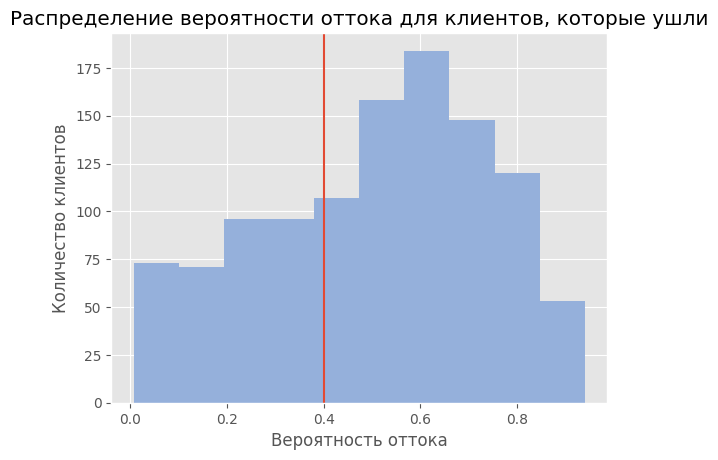

In [93]:
plt.hist(df_proba.loc[df_proba.target == 1, 'proba'], color=COLORS[3], bins = 10)
plt.xlabel('Вероятность оттока')
plt.ylabel('Количество клиентов')
plt.title('Распределение вероятности оттока для клиентов, которые ушли')
plt.axvline(x=0.4)
plt.show()

**Максимальный отток начинается с вероятности 0.4 поэтому необходимо планировать мероприятия к удержанию клиентов с этой вероятности.**

Мероприятия могут быть зачисление бонусов на счет, предоставление приобретения услуг за бонусы и т.д.

### Выводы


***Выпишите какое лучшее качество и с какими параметрами вам удалось получить***

Лучшие параметры:

{'logisticregression__C': 100,

'logisticregression__max_iter': 1000,

'logisticregression__penalty': 'l2',

'logisticregression__solver': 'saga'}

**Лучшая точность: 0.8519652913877328**

## Применение градиентного бустинга (2 балла)

Если вы хотите получить баллы за точный ответ, то стоит попробовать градиентный бустинг. Часто градиентный бустинг с параметрами по умолчанию даст вам 80% результата за 0% усилий.

Мы будем использовать catboost, поэтому нам не надо кодировать категориальные признаки. Catboost сделает это сам (в .fit() надо передать cat_features=cat_cols). А численные признаки нормировать для моделей, основанных на деревьях не нужно.

1) Разделите выборку на train/valid. Протестируйте catboost cо стандартными параметрами.

2) Протестируйте разные занчения параметров количества деревьев и learning_rate'а и выберите лучшую по метрике ROC-AUC комбинацию.

(Дополнительно) Есть некоторые сложности с тем, чтобы использовать CatBoostClassifier вместе с GridSearchCV, поэтому мы не просим использовать кроссвалидацию. Но можете попробовать)

In [94]:
from catboost import CatBoostClassifier

In [95]:
df = pd.read_csv('./train.csv')

In [96]:
df = create_new_features(df)

In [97]:
X_train, X_valid, y_train, y_valid = train_test_split(df.drop(target_col, axis=1), df[target_col], test_size=0.2,
                                                    random_state=42)

In [98]:
FEATURES = X_train.columns.tolist()
CAT_FEATURES_INDICES = [FEATURES.index(cat_feature) for cat_feature in cat_cols + feat_cols]

In [99]:
# Создание модели CatBoost
model = CatBoostClassifier(iterations=100,  # Количество итераций (деревьев)
                           learning_rate=0.1,  # Скорость обучения
                           depth=16,  # Глубина деревьев
                           # loss_function='Logloss',  # Функция потерь
                            eval_metric='AUC',
                           verbose=10)  # Вывод информации о процессе обучения

# Обучение модели

In [100]:
model.fit(X_train, y_train, plot=True, cat_features=CAT_FEATURES_INDICES)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	total: 3.21s	remaining: 5m 18s
10:	total: 10.2s	remaining: 1m 22s
20:	total: 25.3s	remaining: 1m 35s
30:	total: 40.7s	remaining: 1m 30s
40:	total: 1m 1s	remaining: 1m 28s
50:	total: 1m 10s	remaining: 1m 7s
60:	total: 1m 24s	remaining: 54.3s
70:	total: 1m 42s	remaining: 41.7s
80:	total: 2m 4s	remaining: 29.2s
90:	total: 2m 36s	remaining: 15.4s
99:	total: 3m 1s	remaining: 0us


In [101]:
check_metric(model, X_train, y_train, X_valid, y_valid)

 Качество модели на тренировочной выборки: 0.9642323749845637
 Качество модели на валидационной выборки: 0.8010385016761943


> Качество модели сильно отличаются, вероятно наступило переобучение

Выпишите, какое лучшее качество и с какими параметрами вам удалось получить

**Модель catbost обучалась со следующими параметрами**

iterations=100,  

learning_rate=0.1,

depth=16

eval_metric='AUC',

**Качество модели на валидационной выборки: 0.80**

# Предсказания на закрытых данных

> catboost

In [103]:
# best_model =  model

> logisticregression  

In [104]:
best_model =  pipeline

In [105]:
X_test = pd.read_csv('./test.csv')
submission = pd.read_csv('./submission.csv')

> для catboost так как не входит в конвеер

In [178]:
# X_test = create_new_features(X_test)

In [106]:
submission['Churn'] = best_model.predict_proba(X_test)[:,1]

In [107]:
submission.to_csv('./my_submission4.csv', index=False)

Лучшее решение отправьте в Stepik.

> Использую kaggle api для проверки решения

In [108]:
!kaggle competitions submit -c advanced-dls-spring-2021 -f ./my_submission4.csv -m "Мое первое решение catboost"

Successfully submitted to Предсказание оттока пользователей (весна 2021)



  0%|          | 0.00/43.3k [00:00<?, ?B/s]
 37%|###6      | 16.0k/43.3k [00:00<00:00, 104kB/s]
100%|##########| 43.3k/43.3k [00:00<00:00, 47.1kB/s]


In [109]:
!kaggle competitions submissions -c advanced-dls-spring-2021

fileName            date                 description                            status    publicScore  privateScore  
------------------  -------------------  -------------------------------------  --------  -----------  ------------  
my_submission4.csv  2025-03-13 15:49:18  Мое первое решение catboost            complete  0.85121                    
my_submission3.csv  2025-03-12 17:37:01  Мое первое решение catboost            complete  0.83436                    
my_submission2.csv  2025-03-12 17:07:03  Мое первое решение catboost            complete  0.83580                    
my_submission1.csv  2025-03-12 13:25:54  Мое первое решение logisticregression  complete  0.85081                    


 Качество модели на валидационной выборки: 0.8326576222975407